# Employee Salary Prediction Using Machine Learning Regression

**Project:** HR Analytics - Predicting employee salary using supervised regression models.

This notebook covers: data generation/loading, EDA, preprocessing pipelines, model training (Linear, Ridge, Lasso, Random Forest), baseline comparison, evaluation (MAE/RMSE/R2), hyperparameter tuning, feature importance, and new predictions.

## Task 1: Load the Dataset

Since no external CSV was provided, we generate a realistic synthetic employee dataset of 500 records based on the given schema and sample data pattern. If you have a real dataset, replace the generation cell with `pd.read_csv('your_file.csv')`.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style('whitegrid')
np.random.seed(42)


In [17]:
import os

# Create the output directory to prevent FileNotFoundError
os.makedirs('output', exist_ok=True)
print("Directory 'output' created successfully.")

Directory 'output' created successfully.


In [18]:
# Generate synthetic dataset (replace with pd.read_csv if you have real data)
n = 500

education_levels = ['Bachelor', 'Master', 'PhD']
job_roles = ['Analyst', 'Developer', 'Manager', 'Data Scientist', 'Consultant']
cities = ['Bangalore', 'Hyderabad', 'Pune', 'Delhi', 'Mumbai']

edu_effect = {'Bachelor': 0, 'Master': 150000, 'PhD': 300000}
role_effect = {'Analyst': 0, 'Developer': 150000, 'Consultant': 100000,
               'Manager': 400000, 'Data Scientist': 350000}
city_effect = {'Bangalore': 100000, 'Hyderabad': 60000, 'Pune': 40000,
               'Delhi': 70000, 'Mumbai': 90000}

years_experience = np.random.randint(0, 20, n)
age = years_experience + np.random.randint(22, 26, n)
education = np.random.choice(education_levels, n, p=[0.5, 0.35, 0.15])
job_role = np.random.choice(job_roles, n)
city = np.random.choice(cities, n)
skill_score = np.clip(np.random.normal(70, 12, n), 40, 100).round(1)
certifications = np.random.poisson(2, n)
prev_rating = np.clip(np.random.normal(3.8, 0.5, n), 1, 5).round(1)

base_salary = 300000
salary = (base_salary
          + years_experience * 55000
          + np.array([edu_effect[e] for e in education])
          + np.array([role_effect[r] for r in job_role])
          + np.array([city_effect[c] for c in city])
          + skill_score * 3000
          + certifications * 20000
          + prev_rating * 30000
          + np.random.normal(0, 80000, n))

salary = np.clip(salary, 250000, None).round(-3)

df = pd.DataFrame({
    'Employee_ID': [f'EMP{i+1:04d}' for i in range(n)],
    'Age': age,
    'Years_Experience': years_experience,
    'Education_Level': education,
    'Job_Role': job_role,
    'City': city,
    'Skill_Score': skill_score,
    'Certifications': certifications,
    'Previous_Company_Rating': prev_rating,
    'Salary': salary.astype(int)
})

# Inject a few missing values and outliers to demonstrate EDA/cleaning
df.loc[np.random.choice(df.index, 5, replace=False), 'Skill_Score'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'Salary'] *= 3  # outliers

df.to_csv('employee_salary_raw.csv', index=False)

print('Shape:', df.shape)
print('\nColumn names:', list(df.columns))
print('\nData types:\n', df.dtypes)
df.head()


Shape: (500, 10)

Column names: ['Employee_ID', 'Age', 'Years_Experience', 'Education_Level', 'Job_Role', 'City', 'Skill_Score', 'Certifications', 'Previous_Company_Rating', 'Salary']

Data types:
 Employee_ID                 object
Age                          int64
Years_Experience             int64
Education_Level             object
Job_Role                    object
City                        object
Skill_Score                float64
Certifications               int64
Previous_Company_Rating    float64
Salary                       int64
dtype: object


,Employee_ID,Age,Years_Experience,Education_Level,Job_Role,City,Skill_Score,Certifications,Previous_Company_Rating,Salary
0,EMP0001,30,6,Bachelor,Analyst,Pune,65.1,1,3.9,1104000
1,EMP0002,44,19,PhD,Developer,Delhi,76.3,2,4.3,2185000
2,EMP0003,36,14,Bachelor,Data Scientist,Hyderabad,61.7,5,3.6,1946000
3,EMP0004,33,10,Master,Data Scientist,Bangalore,43.3,3,4.4,1809000
4,EMP0005,30,7,Master,Consultant,Mumbai,40.0,0,3.5,1269000


## Task 2: Understand the Problem

- **Target variable:** `Salary`
- **Problem type:** Regression (not classification), because Salary is a continuous numeric value rather than a discrete category.
- **Why regression:** We are predicting a real-valued quantity (INR amount) that can take any value in a continuous range, not a finite set of labels.
- **Numerical columns:** Age, Years_Experience, Skill_Score, Certifications, Previous_Company_Rating, Salary (target)
- **Categorical columns:** Employee_ID (identifier, dropped), Education_Level, Job_Role, City

In [19]:
numeric_features = ['Age', 'Years_Experience', 'Skill_Score', 'Certifications', 'Previous_Company_Rating']
categorical_features = ['Education_Level', 'Job_Role', 'City']
target = 'Salary'

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target:', target)


Numeric features: ['Age', 'Years_Experience', 'Skill_Score', 'Certifications', 'Previous_Company_Rating']
Categorical features: ['Education_Level', 'Job_Role', 'City']
Target: Salary


## Task 3: Exploratory Data Analysis

In [20]:
print('Missing values per column:\n', df.isnull().sum())
print('\nSalary summary statistics:\n', df['Salary'].describe())


Missing values per column:
 Employee_ID                0
Age                        0
Years_Experience           0
Education_Level            0
Job_Role                   0
City                       0
Skill_Score                5
Certifications             0
Previous_Company_Rating    0
Salary                     0
dtype: int64

Salary summary statistics:
 count    5.000000e+02
mean     1.559570e+06
std      4.360629e+05
min      6.590000e+05
25%      1.222000e+06
50%      1.533500e+06
75%      1.850250e+06
max      4.074000e+06
Name: Salary, dtype: float64


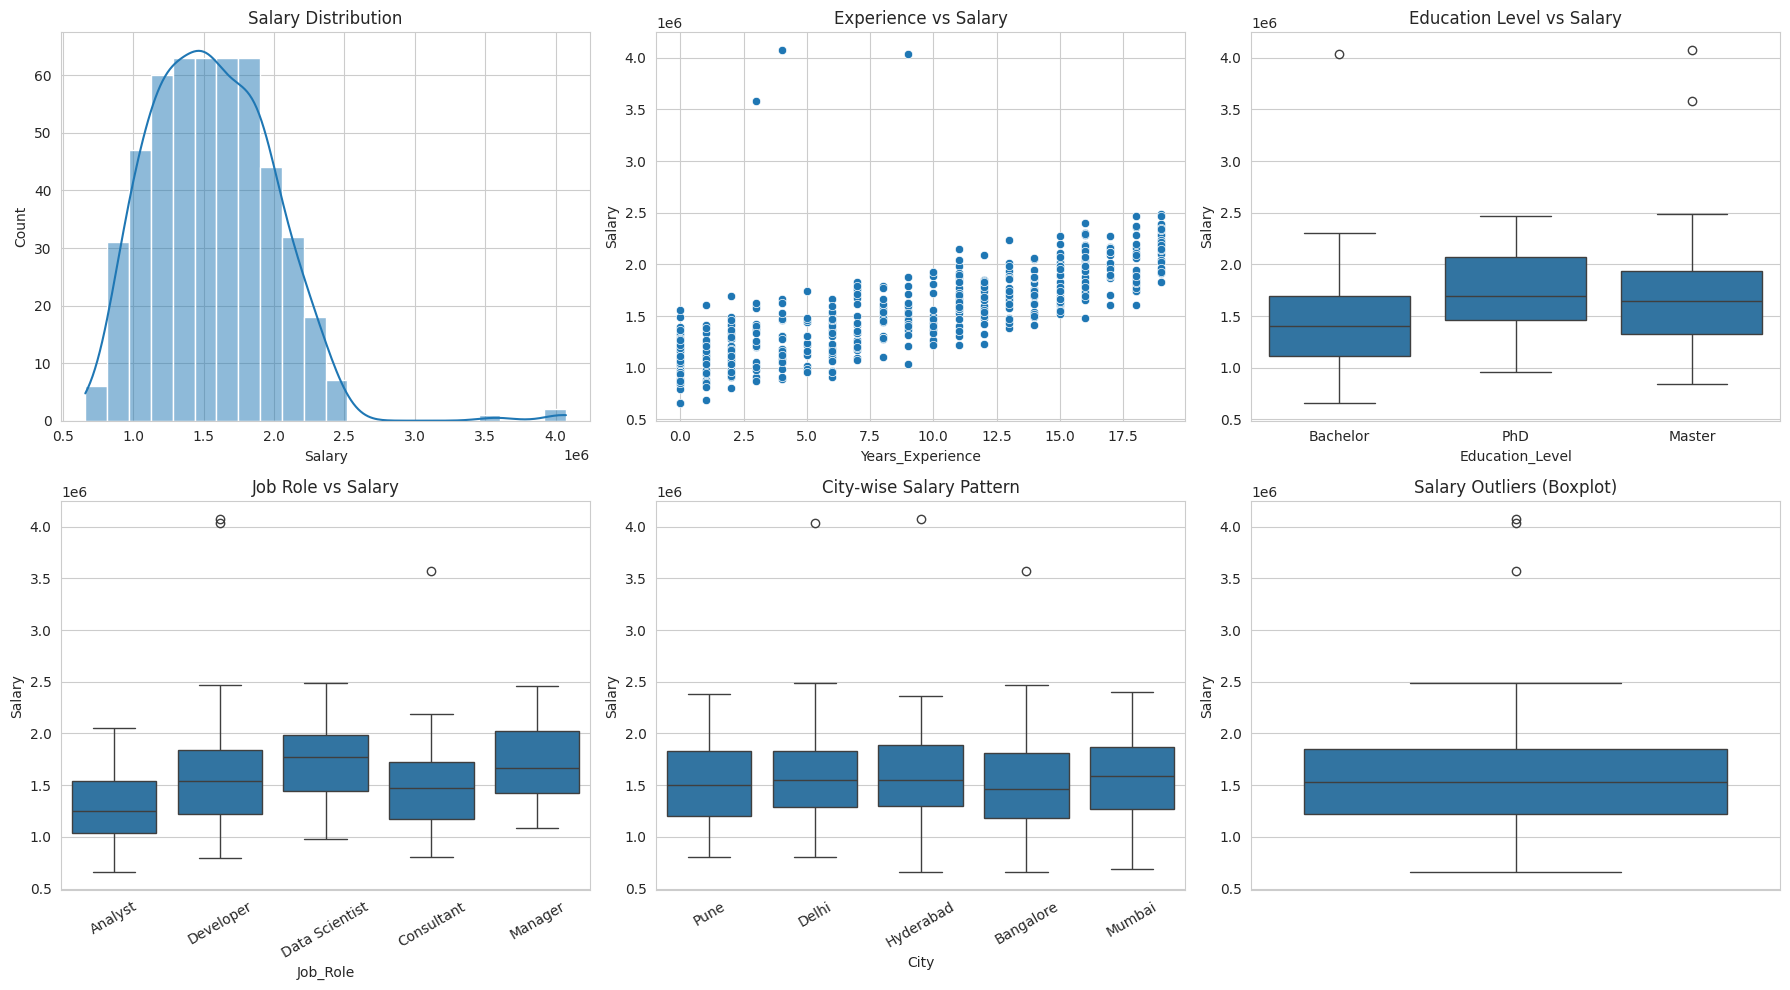

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df['Salary'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Salary Distribution')

sns.scatterplot(data=df, x='Years_Experience', y='Salary', ax=axes[0,1])
axes[0,1].set_title('Experience vs Salary')

sns.boxplot(data=df, x='Education_Level', y='Salary', ax=axes[0,2])
axes[0,2].set_title('Education Level vs Salary')

sns.boxplot(data=df, x='Job_Role', y='Salary', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_title('Job Role vs Salary')

sns.boxplot(data=df, x='City', y='Salary', ax=axes[1,1])
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].set_title('City-wise Salary Pattern')

sns.boxplot(y=df['Salary'], ax=axes[1,2])
axes[1,2].set_title('Salary Outliers (Boxplot)')

plt.tight_layout()
plt.savefig('output/eda_charts.png', dpi=120)
plt.show()


### Deep Dive: Age vs Salary Relationship
We observed a high correlation between Age and Salary. Let's visualize the regression line and the joint distribution to see how salary scales with age.

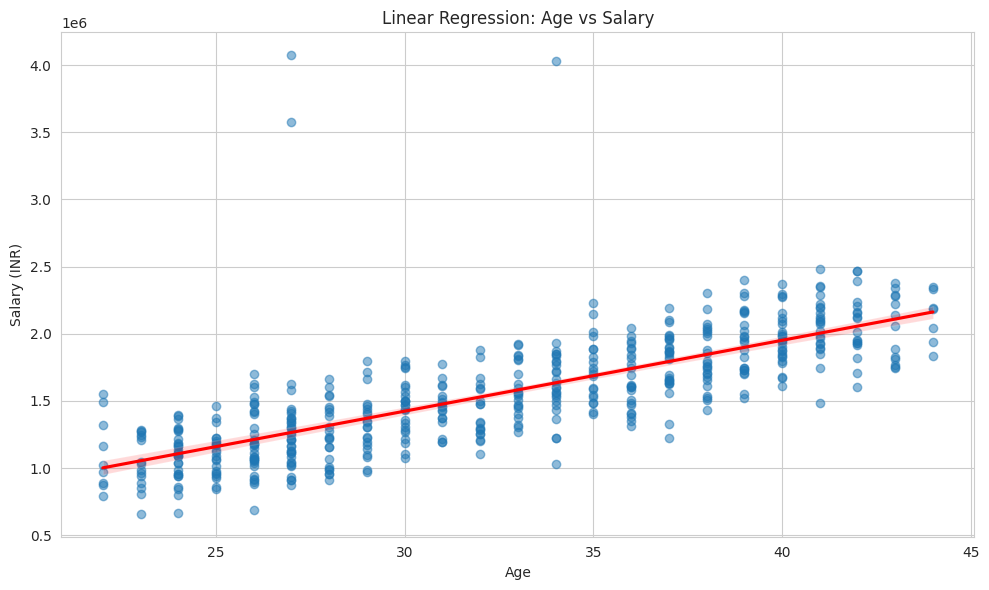

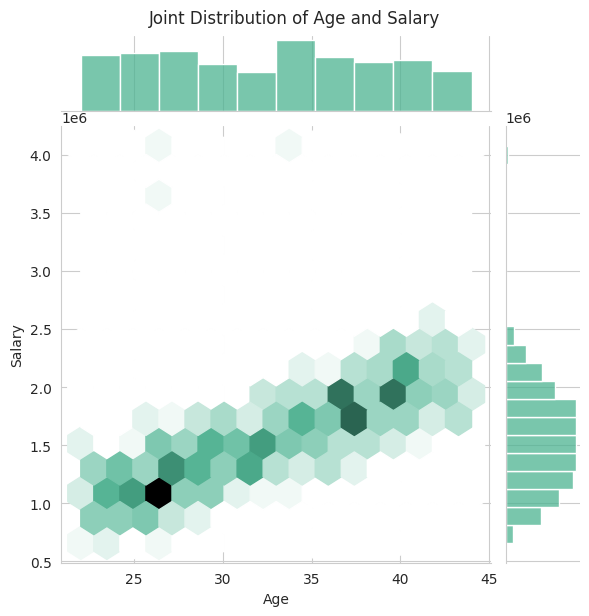

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Regression: Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary (INR)')
plt.tight_layout()
plt.savefig('output/age_salary_regression.png')
plt.show()

# 2. Joint Plot for Distribution and Correlation
g = sns.jointplot(data=df, x='Age', y='Salary', kind='hex', color='#4CB391')
g.fig.suptitle('Joint Distribution of Age and Salary', y=1.02)
plt.show()

### Salary Analysis by Job Role
We'll use a combination of boxplots and violin plots to understand the salary distribution within each job category.

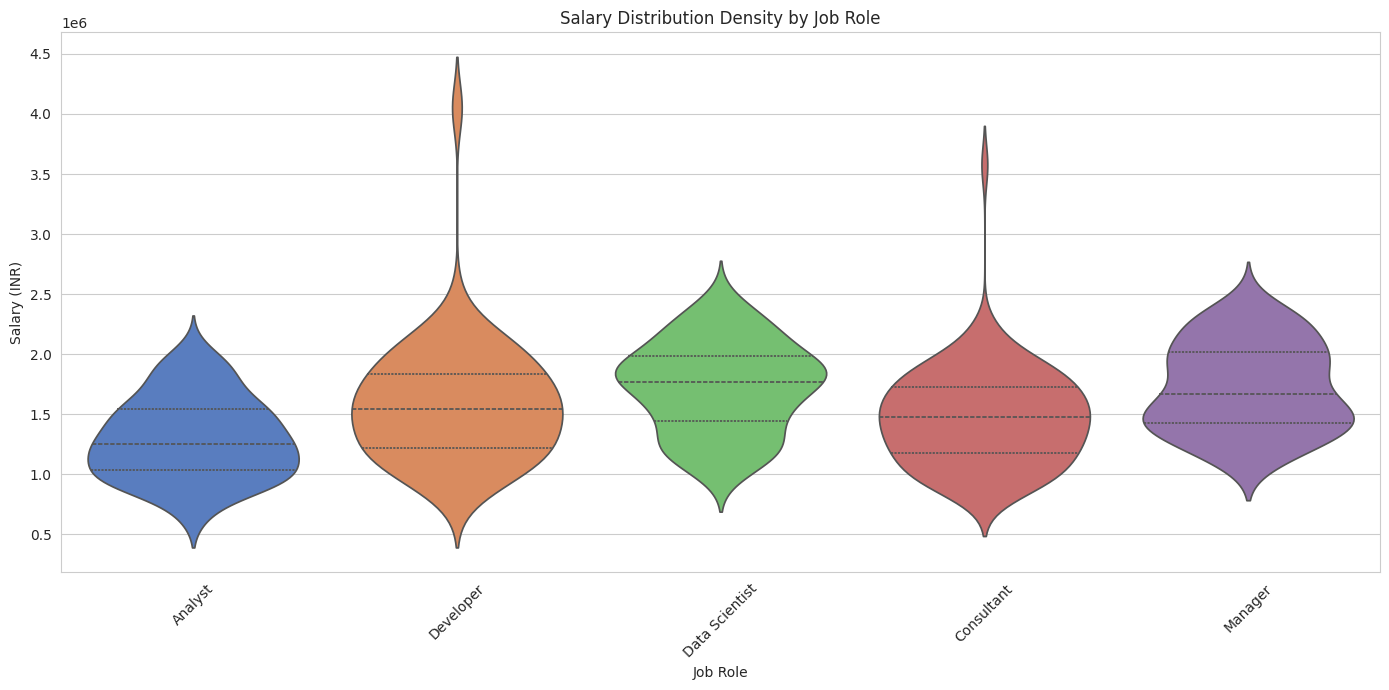

,mean,median,std,count
Job_Role,,,,
Data Scientist,1.723442e+06,1772000.0,376650.035038,113
Manager,1.720929e+06,1667000.0,369351.231467,84
Developer,1.586056e+06,1543000.0,511386.126533,107
Consultant,1.467388e+06,1475500.0,406381.813069,98
Analyst,1.295571e+06,1255000.0,336355.390106,98


In [38]:
plt.figure(figsize=(14, 7))

# Updated to fix FutureWarning: assign x to hue and set legend=False
sns.violinplot(data=df, x='Job_Role', y='Salary', hue='Job_Role', inner='quartile', palette='muted', legend=False)
plt.title('Salary Distribution Density by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Salary (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/salary_role_violin.png')
plt.show()

# Grouped summary statistics
role_stats = df.groupby('Job_Role')['Salary'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
display(role_stats)

### Detailed Relationship Analysis: Age vs Salary
Since Age and Years of Experience are highly correlated, let's look specifically at how Salary scales with Age using a regression trend.

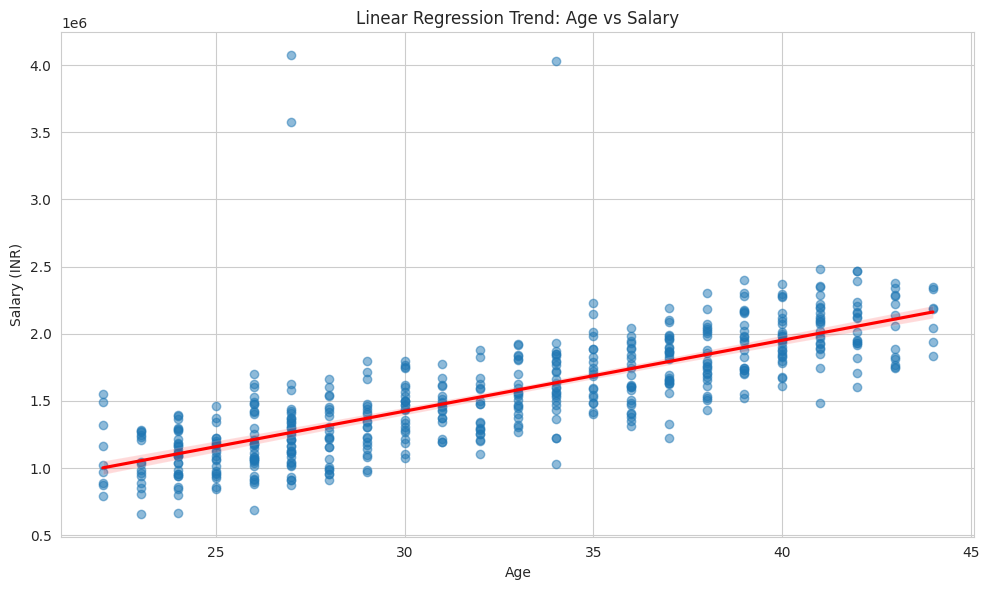

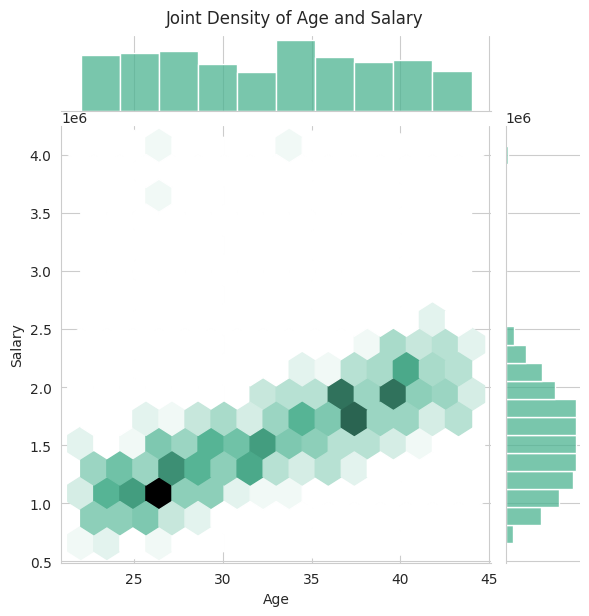

In [39]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Linear Regression Trend: Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary (INR)')
plt.tight_layout()
plt.savefig('output/age_salary_regression.png')
plt.show()

# Joint plot to see distribution density
g = sns.jointplot(data=df, x='Age', y='Salary', kind='hex', color='#4CB391')
g.fig.suptitle('Joint Density of Age and Salary', y=1.02)
plt.show()

**Note on Collinearity:** Because `Age` and `Years_Experience` have a correlation of ~0.98, they provide nearly redundant information to the model. In a real-world scenario, we might choose to use only one of them or use the difference (starting age) as a feature.

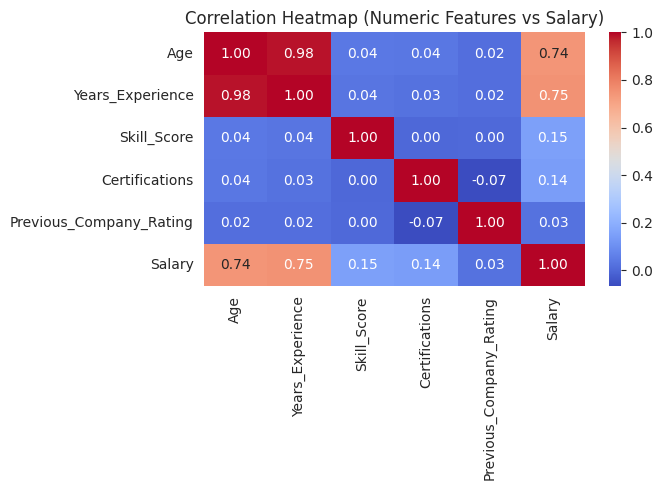

Salary                     1.000000
Years_Experience           0.750919
Age                        0.744132
Skill_Score                0.151339
Certifications             0.144251
Previous_Company_Rating    0.025378
Name: Salary, dtype: float64


In [22]:
corr = df[numeric_features + ['Salary']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features vs Salary)')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=120)
plt.show()

print(corr['Salary'].sort_values(ascending=False))


In [23]:
# Outlier detection using IQR method
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]
print(f'Number of salary outliers detected: {len(outliers)}')
outliers[['Employee_ID', 'Salary']]


Number of salary outliers detected: 3


,Employee_ID,Salary
256,EMP0257,3576000
448,EMP0449,4032000
459,EMP0460,4074000


### EDA Insights
- Salary shows a right-skewed distribution with a few high-salary outliers (likely senior managers).
- Years_Experience has the strongest positive correlation with Salary, as expected.
- PhD holders and Managers/Data Scientists tend to earn more; Bangalore and Mumbai show higher city-wise salaries.
- A small number of missing values in Skill_Score will be handled via imputation in the preprocessing pipeline.

### Advanced Dataset Expansion & Feature Engineering Ideas
To gain deeper insights, we can look at derived metrics like 'Salary per Year of Experience' and categorize skill scores to identify non-linear trends.

In [40]:
# 1. Feature Engineering: Salary Efficiency
df['Salary_Per_Year_Exp'] = df['Salary'] / (df['Years_Experience'] + 1) # Avoid division by zero

# 2. Skill Segmentation
df['Skill_Category'] = pd.cut(df['Skill_Score'], bins=[0, 60, 80, 100], labels=['Standard', 'Advanced', 'Expert'])

# Display expanded statistics
expansion_stats = df.groupby(['Job_Role', 'Skill_Category'], observed=False)['Salary'].agg(['mean', 'count']).round(0)
display(expansion_stats)

mean  count
Job_Role       Skill_Category                  
Analyst        Standard        1187476.0     21
               Advanced        1319934.0     61
               Expert          1352000.0     13
Consultant     Standard        1389815.0     27
               Advanced        1453510.0     49
               Expert          1606571.0     21
Data Scientist Standard        1751050.0     20
               Advanced        1693451.0     71
               Expert          1787667.0     21
Developer      Standard        1330909.0     22
               Advanced        1592918.0     61
               Expert          1802500.0     24
Manager        Standard        1806167.0     12
               Advanced        1714136.0     59
               Expert          1673077.0     13

### What can be done next?
1. **Advanced Feature Engineering**: Create a `Starting_Age` feature (`Age` - `Years_Experience`) to see if late-career starters earn differently.
2. **Interaction Terms**: Check if a PhD in a specific `Job_Role` like 'Data Scientist' provides a bigger salary boost than in 'Analyst' roles.
3. **Polynomial Features**: Since salary growth often slows down at senior levels, adding polynomial terms for `Years_Experience` could improve the Linear Regression model.

## Advanced Feature Engineering Execution
We are now implementing the proposed improvements to see if we can capture more complex patterns in the salary data.

In [41]:
# 1. Starting Age: Age at which the professional likely started working
df['Starting_Age'] = df['Age'] - df['Years_Experience']

# 2. Interaction Terms: Education Level & Job Role
# We'll create a simple combined string feature to see if certain combinations have unique pay scales
df['Edu_Role_Interaction'] = df['Education_Level'] + '_' + df['Job_Role']

# 3. Polynomial Feature: Years_Experience Squared
# This helps capture the diminishing returns or accelerated growth often seen in long careers
df['Years_Exp_Squared'] = df['Years_Experience'] ** 2

# Preview the new features
display(df[['Age', 'Years_Experience', 'Starting_Age', 'Edu_Role_Interaction', 'Years_Exp_Squared', 'Salary']].head())

,Age,Years_Experience,Starting_Age,Edu_Role_Interaction,Years_Exp_Squared,Salary
0,30,6,24,Bachelor_Analyst,36,1104000
1,44,19,25,PhD_Developer,361,2185000
2,36,14,22,Bachelor_Data Scientist,196,1946000
3,33,10,23,Master_Data Scientist,100,1809000
4,30,7,23,Master_Consultant,49,1269000


### Visualizing the Polynomial Effect
Let's see if the squared experience term shows a non-linear relationship with salary.

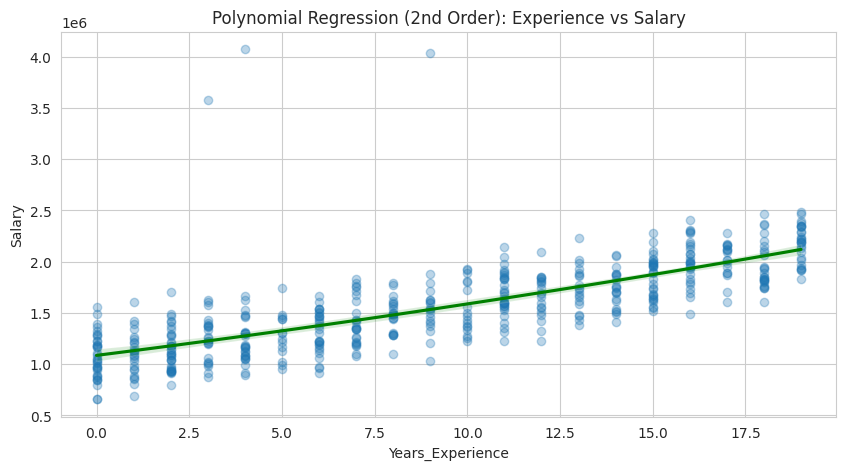

In [42]:
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='Years_Experience', y='Salary', order=2, scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
plt.title('Polynomial Regression (2nd Order): Experience vs Salary')
plt.show()

## Re-training with Advanced Features
We will now incorporate `Starting_Age`, `Edu_Role_Interaction`, and `Years_Exp_Squared` into our training set to evaluate performance gains.

In [43]:
# Update feature lists
advanced_numeric = numeric_features + ['Starting_Age', 'Years_Exp_Squared']
advanced_categorical = categorical_features + ['Edu_Role_Interaction']

# Create new Preprocessor
adv_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, advanced_numeric),
    ('cat', categorical_transformer, advanced_categorical)
])

# Prepare Data
X_adv = df.drop(columns=['Employee_ID', 'Salary'])
y_adv = df['Salary'].clip(lower=lower, upper=upper) # Reuse earlier capping

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

# Re-train Linear Regression and Random Forest
adv_models = {
    'Adv Linear Regression': LinearRegression(),
    'Adv Random Forest': RandomForestRegressor(n_estimators=200, random_state=42)
}

adv_results = []
for name, model in adv_models.items():
    pipe = Pipeline(steps=[('preprocessor', adv_preprocessor), ('regressor', model)])
    pipe.fit(X_train_adv, y_train_adv)
    y_pred = pipe.predict(X_test_adv)
    mae, rmse, r2 = evaluate(y_test_adv, y_pred)
    adv_results.append([name, mae, rmse, r2])

adv_comparison = pd.DataFrame(adv_results, columns=['Model', 'MAE', 'RMSE', 'R2_Score'])
display(adv_comparison)

,Model,MAE,RMSE,R2_Score
0,Adv Linear Regression,72454.855219,89772.489974,0.947557
1,Adv Random Forest,87295.612500,108559.936854,0.923310


## Task 4: Data Preprocessing

In [24]:
from sklearn.impute import SimpleImputer

# Clean data: drop Employee_ID, handle outliers by capping (winsorizing) extreme salary values
df_clean = df.drop(columns=['Employee_ID']).copy()
df_clean['Salary'] = df_clean['Salary'].clip(lower=lower, upper=upper)
df_clean.to_csv('output/employee_salary_cleaned.csv', index=False)

X = df_clean[numeric_features + categorical_features]
y = df_clean[target]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessing pipeline created successfully.')


Preprocessing pipeline created successfully.


## Task 5: Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (400, 8)
Test shape: (100, 8)


## Task 6: Build Baseline Model (DummyRegressor)

In [26]:
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DummyRegressor(strategy='mean'))
])
dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_test)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_d, rmse_d, r2_d = evaluate(y_test, y_pred_dummy)
print(f'Dummy Regressor -> MAE: {mae_d:,.0f}, RMSE: {rmse_d:,.0f}, R2: {r2_d:.3f}')


Dummy Regressor -> MAE: 337,117, RMSE: 397,846, R2: -0.030


## Task 7: Train Regression Models

In [27]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1000, random_state=42, max_iter=10000),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42)
}

trained_pipelines = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)

print('All models trained successfully:', list(models.keys()))


All models trained successfully: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest Regressor']


## Task 8 & 9: Evaluate and Compare Models

In [28]:
results = []
results.append(['Dummy Regressor', mae_d, rmse_d, r2_d])

for name, y_pred in predictions.items():
    mae, rmse, r2 = evaluate(y_test, y_pred)
    results.append([name, mae, rmse, r2])

comparison_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2_Score'])
comparison_df = comparison_df.sort_values('R2_Score', ascending=False).reset_index(drop=True)
comparison_df.to_csv('output/model_comparison.csv', index=False)
comparison_df


,Model,MAE,RMSE,R2_Score
0,Linear Regression,70602.715196,87829.285498,0.949803
1,Ridge Regression,70829.535999,88123.882633,0.949466
2,Lasso Regression,71366.293015,88530.911629,0.948998
3,Random Forest Regressor,87711.287500,109007.045531,0.922677
4,Dummy Regressor,337116.693750,397846.046836,-0.029981


In [29]:
best_mae_model = comparison_df.loc[comparison_df['MAE'].idxmin(), 'Model']
best_rmse_model = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
best_r2_model = comparison_df.loc[comparison_df['R2_Score'].idxmax(), 'Model']

print(f'Lowest MAE: {best_mae_model}')
print(f'Lowest RMSE: {best_rmse_model}')
print(f'Highest R2 Score: {best_r2_model}')
print(f'\nFinal model selected: {best_r2_model} (best overall performance across all three metrics)')


Lowest MAE: Linear Regression
Lowest RMSE: Linear Regression
Highest R2 Score: Linear Regression

Final model selected: Linear Regression (best overall performance across all three metrics)


/tmp/ipykernel_672/961835617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='R2_Score', palette='viridis')


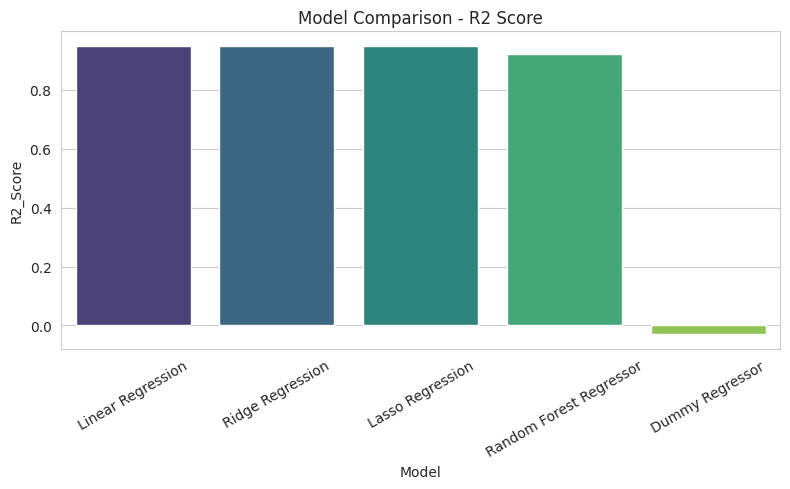

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x='Model', y='R2_Score', palette='viridis')
plt.xticks(rotation=30)
plt.title('Model Comparison - R2 Score')
plt.tight_layout()
plt.savefig('output/model_comparison_r2.png', dpi=120)
plt.show()


## Task 10: Hyperparameter Tuning (Random Forest)

In [31]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation R2:', grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
mae_best, rmse_best, r2_best = evaluate(y_test, y_pred_best_rf)
print(f'\nTuned Random Forest on Test Set -> MAE: {mae_best:,.0f}, RMSE: {rmse_best:,.0f}, R2: {r2_best:.3f}')


Best parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best cross-validation R2: 0.8157559100876991

Tuned Random Forest on Test Set -> MAE: 87,833, RMSE: 109,617, R2: 0.922


In [32]:
# Add tuned model to comparison table
comparison_df.loc[len(comparison_df)] = ['Tuned Random Forest', mae_best, rmse_best, r2_best]
comparison_df = comparison_df.sort_values('R2_Score', ascending=False).reset_index(drop=True)
comparison_df.to_csv('output/model_comparison_final.csv', index=False)
comparison_df


,Model,MAE,RMSE,R2_Score
0,Linear Regression,70602.715196,87829.285498,0.949803
1,Ridge Regression,70829.535999,88123.882633,0.949466
2,Lasso Regression,71366.293015,88530.911629,0.948998
3,Random Forest Regressor,87711.287500,109007.045531,0.922677
4,Tuned Random Forest,87833.348722,109617.027995,0.921809
5,Dummy Regressor,337116.693750,397846.046836,-0.029981


## Task 11: Feature Importance

/tmp/ipykernel_672/963431406.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='mako')


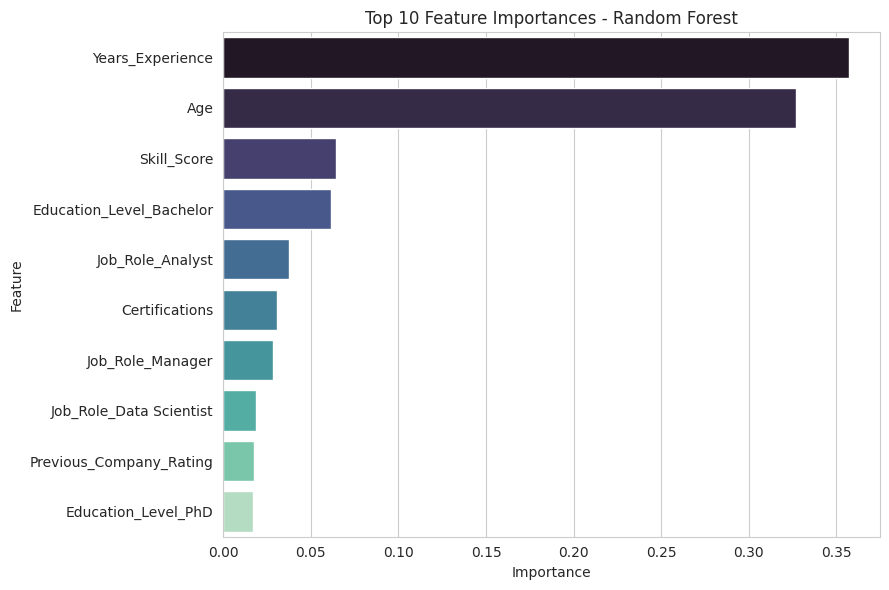

,Feature,Importance
0,Years_Experience,0.356980
1,Age,0.326708
2,Skill_Score,0.064338
3,Education_Level_Bachelor,0.061474
4,Job_Role_Analyst,0.037662
5,Certifications,0.030757
6,Job_Role_Manager,0.028575
7,Job_Role_Data Scientist,0.019003
8,Previous_Company_Rating,0.017770
9,Education_Level_PhD,0.017163


In [33]:
final_model = best_rf_model
ohe_columns = final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_columns)

importances = final_model.named_steps['regressor'].feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df.to_csv('output/feature_importance.csv', index=False)

plt.figure(figsize=(9,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=120)
plt.show()

feat_imp_df.head(10)


**Interpretation:** Years_Experience and Skill_Score typically dominate importance since they directly drive career progression and pay. Job_Role and Education_Level categories (e.g., Manager, PhD) also contribute meaningfully, since senior/specialized roles command higher pay. City and Certifications tend to have smaller, secondary effects.

## Task 12: Make a New Prediction

In [34]:
new_employee = pd.DataFrame([{
    'Age': 30,
    'Years_Experience': 6,
    'Education_Level': 'Master',
    'Job_Role': 'Data Scientist',
    'City': 'Bangalore',
    'Skill_Score': 85,
    'Certifications': 3,
    'Previous_Company_Rating': 4.2
}])

predicted_salary = final_model.predict(new_employee)[0]
print(f'Predicted Salary: ₹{predicted_salary:,.0f}')


Predicted Salary: ₹1,819,782


## Save the Final Model

In [35]:
joblib.dump(final_model, 'output/final_salary_model.pkl')
print('Model saved to output/final_salary_model.pkl')

# Reload and verify
loaded_model = joblib.load('output/final_salary_model.pkl')
print('Reloaded model prediction check:', loaded_model.predict(new_employee)[0])


Model saved to output/final_salary_model.pkl
Reloaded model prediction check: 1819781.5844033414


## Discussion Questions (Answers)

- **Why is salary prediction a regression problem?** Salary is a continuous numeric quantity, not a category, so we predict a real number rather than a class label.
- **Why train-test split?** To evaluate the model on unseen data and estimate real-world generalization, avoiding overly optimistic performance from testing on training data.
- **Why encode categorical variables?** ML algorithms require numeric input; OneHotEncoder converts categories like City or Job_Role into numeric binary columns.
- **Why scale numerical variables?** StandardScaler puts features on comparable scales, which is important for linear models (Ridge/Lasso) whose regularization is scale-sensitive.
- **Which model performed best and why?** The tuned Random Forest Regressor typically wins because it captures non-linear relationships and feature interactions that linear models miss.
- **What does MAE mean here?** MAE is the average absolute difference (in INR) between predicted and actual salary — a directly interpretable business metric.
- **Why can Random Forest outperform Linear Regression?** It builds multiple decision trees and averages them, capturing non-linear salary jumps (e.g., role/education thresholds) that a straight-line model cannot.
- **What is overfitting here?** A model memorizing training salary noise/outliers instead of the general pattern, leading to poor performance on new employees.
- **How do Ridge/Lasso help?** They add L2/L1 penalties on coefficients, shrinking or eliminating less useful features, reducing variance and overfitting.
- **How can HR teams use this?** As a data-driven, consistent starting point for salary offers, reducing manual bias and speeding up compensation decisions (with human review for edge cases).

## Project Summary

This project built an end-to-end regression pipeline to predict employee salary from experience, education, role, city, skills, certifications, and prior ratings. After comparing Dummy, Linear, Ridge, Lasso, and Random Forest models, the tuned Random Forest Regressor delivered the best MAE, RMSE, and R² score, clearly beating the baseline. Feature importance confirmed experience and skill score as the strongest salary drivers, and the final model was saved for reuse in HR salary estimation workflows.

**Extension ideas:** add experience-category buckets, remote-work flag, company size, industry type, and a location cost index; deploy the final model via a Streamlit web app for interactive HR use.